# data Analysis of Dirty house cafe Sales

# Import Libraries and Load dataset
These libraries are used for data manipulation, analysis, and visualization.
Pandas for data handling, NumPy for calculations, Matplotlib and Seaborn for visualization.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset into a DataFrame for analysis
df = pd.read_csv("/Users/sijanshrestha/Downloads/dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


# Basic Information

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [88]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [89]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [90]:
# Check for missing values to identify incomplete records
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [91]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [92]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [93]:
df.columns=df.columns.str.lower().str.strip()
df.columns

Index(['transaction id', 'item', 'quantity', 'price per unit', 'total spent',
       'payment method', 'location', 'transaction date'],
      dtype='object')

# Visualization of Missing Values in the Dataset

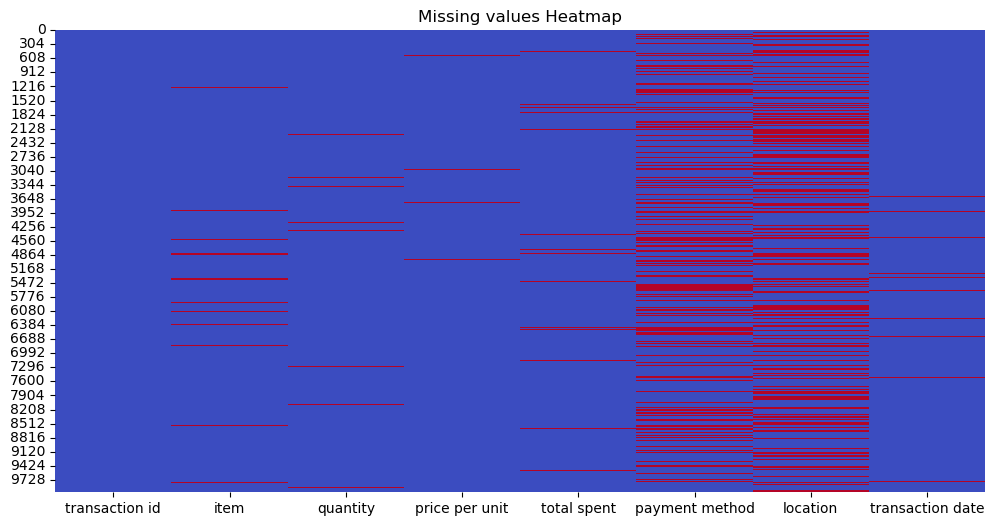

In [94]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='coolwarm')
plt.title("Missing values Heatmap")
plt.show()

In [95]:
values=[
    'N/A',
    'ERROR',
    'NOT AVAILABLE',
    'not available',
    'UNKNOWN',
    ' '
]
df.replace(values,np.nan,inplace=True)

# Fill missing values

In [96]:
df['quantity']=pd.to_numeric(df['quantity'],errors='coerce')
df['quantity']=df['quantity'].fillna(df['quantity'].median())
df['quantity']

0       2.0
1       4.0
2       4.0
3       2.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    4.0
9998    3.0
9999    3.0
Name: quantity, Length: 10000, dtype: float64

In [97]:
df['total spent']=pd.to_numeric(df['total spent'],errors='coerce')
df['total spent']=df['total spent'].fillna(df['total spent'].median())
df['total spent']

0        4.0
1       12.0
2        8.0
3       10.0
4        4.0
        ... 
9995     4.0
9996     3.0
9997     8.0
9998     3.0
9999    12.0
Name: total spent, Length: 10000, dtype: float64

In [98]:
df['price per unit']=pd.to_numeric(df['price per unit'],errors='coerce')
df['price per unit']=df['price per unit'].fillna(df['price per unit'].median())
df['price per unit']

0       2.0
1       3.0
2       1.0
3       5.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    2.0
9998    3.0
9999    4.0
Name: price per unit, Length: 10000, dtype: float64

In [99]:
df['payment method'] = df['payment method'].fillna(df['payment method'].mode()[0])
df['payment method']

0          Credit Card
1                 Cash
2          Credit Card
3       Digital Wallet
4       Digital Wallet
             ...      
9995    Digital Wallet
9996    Digital Wallet
9997    Digital Wallet
9998    Digital Wallet
9999              Cash
Name: payment method, Length: 10000, dtype: object

In [100]:
df['item'] = df['item'].fillna(df['item'].mode()[0])
df['item']

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996       Juice
9997      Coffee
9998      Cookie
9999    Sandwich
Name: item, Length: 10000, dtype: object

In [101]:
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['location']

0       Takeaway
1       In-store
2       In-store
3       Takeaway
4       In-store
          ...   
9995    Takeaway
9996    Takeaway
9997    Takeaway
9998    Takeaway
9999    In-store
Name: location, Length: 10000, dtype: object

In [102]:
df['transaction date'] = df['transaction date'].ffill()
df['transaction date']

0       2023-09-08
1       2023-05-16
2       2023-07-19
3       2023-04-27
4       2023-06-11
           ...    
9995    2023-08-30
9996    2023-06-02
9997    2023-03-02
9998    2023-12-02
9999    2023-11-07
Name: transaction date, Length: 10000, dtype: object

In [123]:
df.isnull().sum()

transaction id      0
item                0
quantity            0
price per unit      0
total spent         0
payment method      0
location            0
transaction date    0
dtype: int64

# Histogram

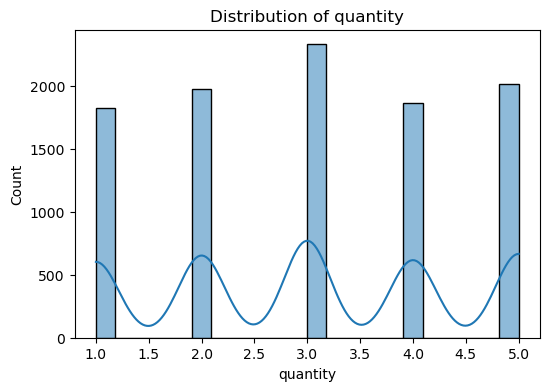

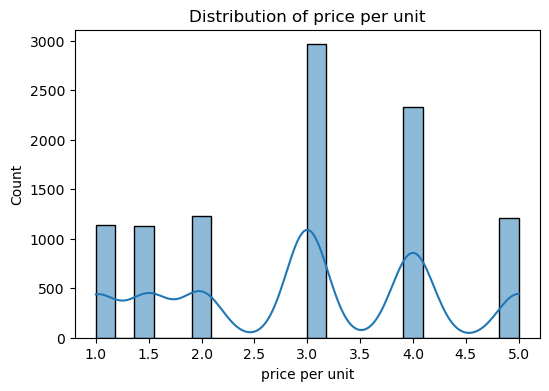

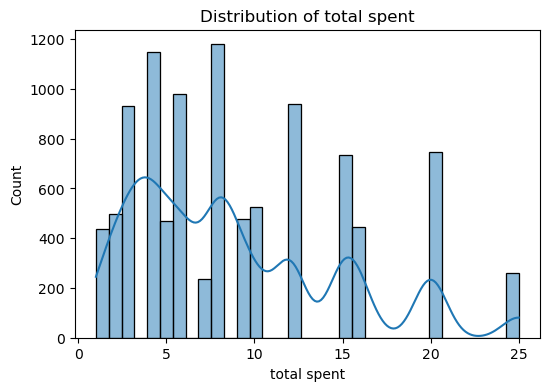

In [104]:
# Histogram shows the distribution of quantity, price per unit and total spending
numeric_cols = ['quantity', 'price per unit', 'total spent']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Boxplot

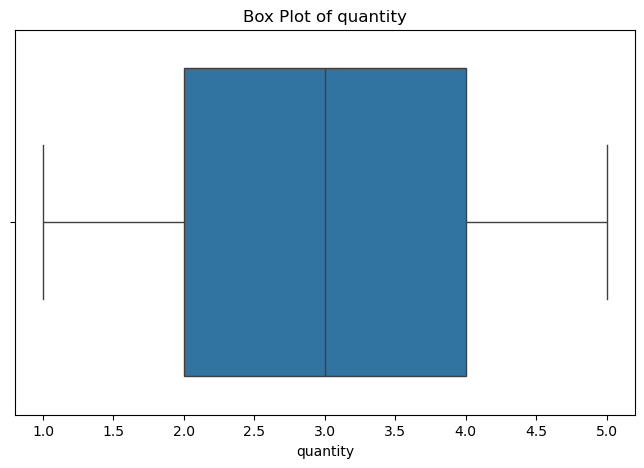

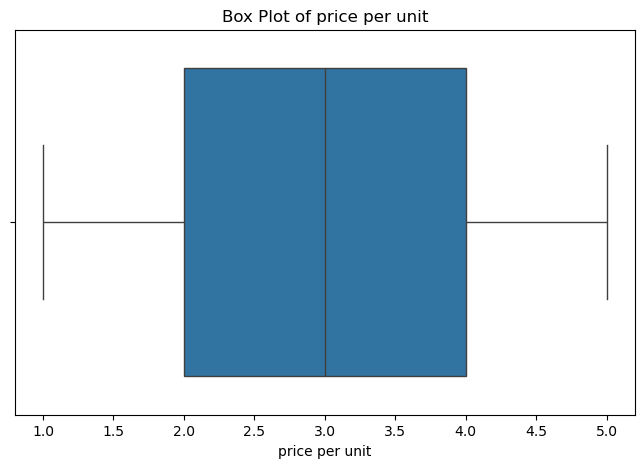

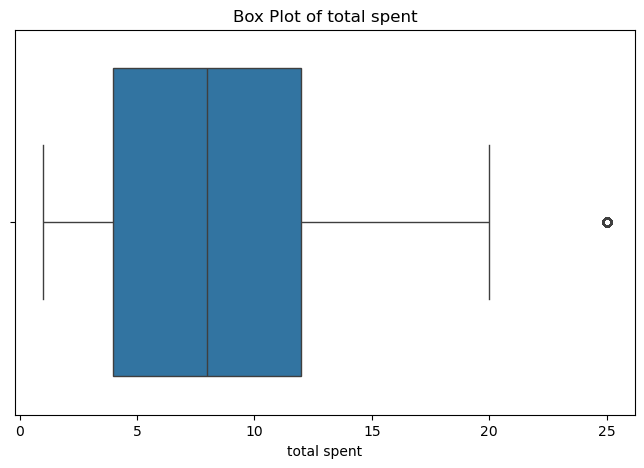

In [105]:
numeric_cols = ['quantity', 'price per unit', 'total spent']

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

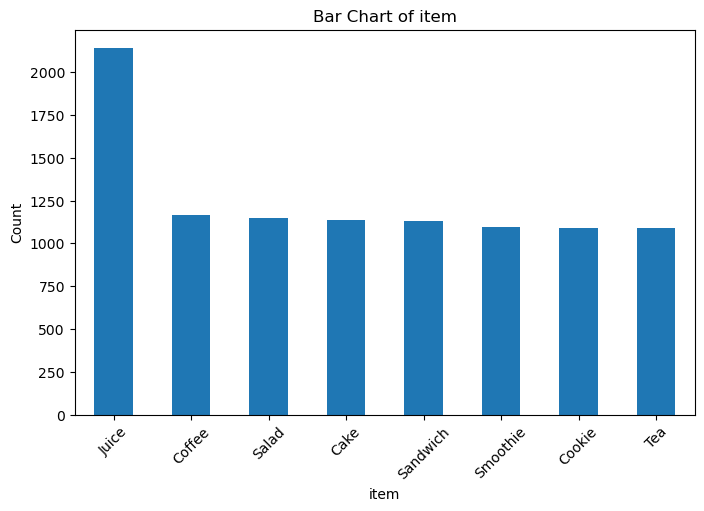

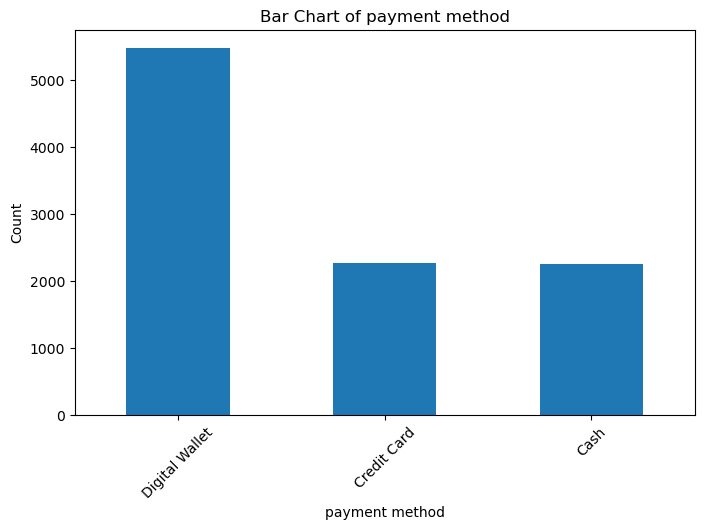

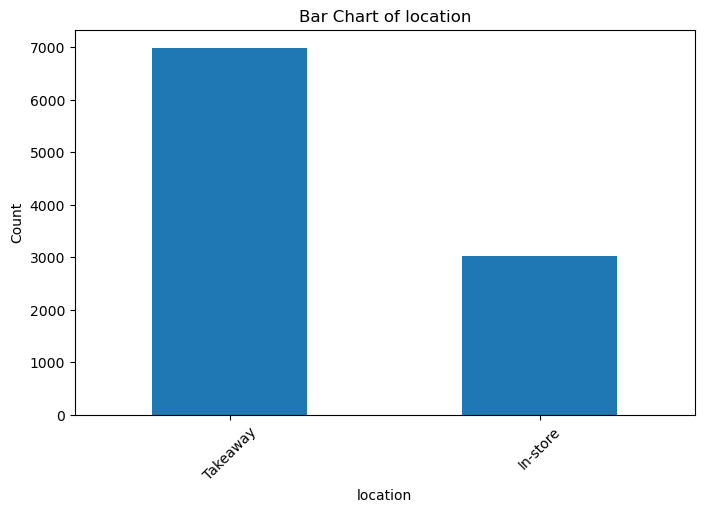

In [106]:
categorical_cols = ['item', 'payment method', 'location']

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# Scatterplot

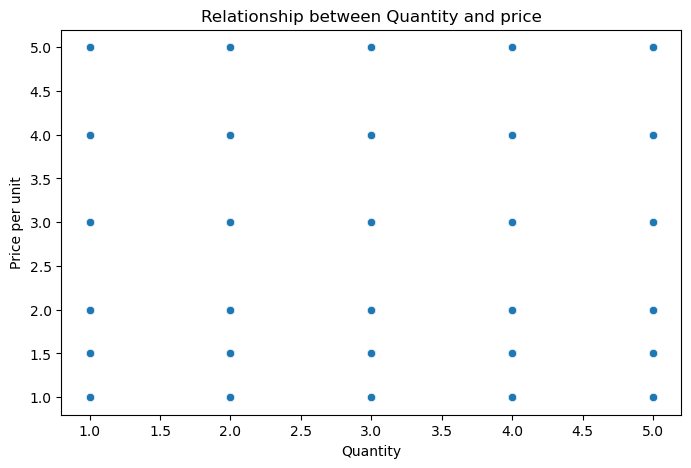

In [107]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='quantity',
    y='price per unit',
    data=df
)
plt.title("Relationship between Quantity and price")
plt.xlabel("Quantity")
plt.ylabel("Price per unit")
plt.show()

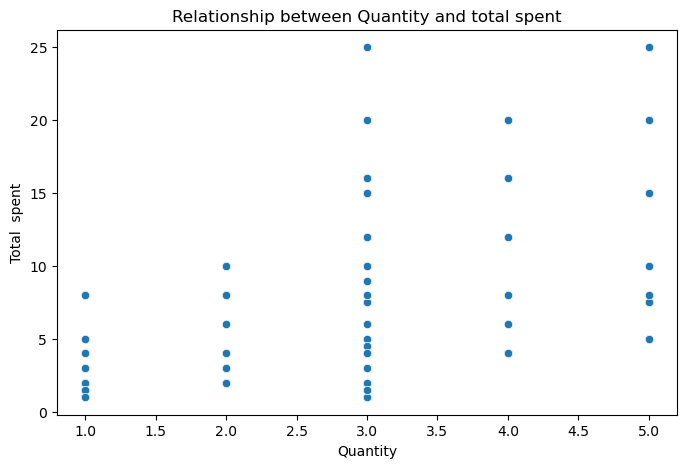

In [108]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='quantity',
    y='total spent',
    data=df
)
plt.title("Relationship between Quantity and total spent")
plt.xlabel("Quantity")
plt.ylabel("Total  spent")
plt.show()

# Correlation

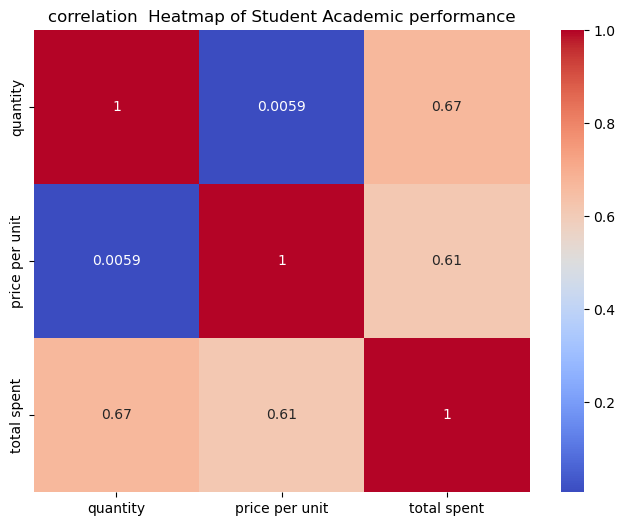

In [109]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot = True,
    cmap = 'coolwarm'
)
plt.title("correlation  Heatmap of Student Academic performance")
plt.show()

# Descriptive Statictics

# Calculate mean

In [110]:
df[['quantity', 'price per unit', 'total spent']].mean().to_frame(name="Mean")

,Mean
quantity,3.02710
price per unit,2.95265
total spent,8.87795


# calculate median

In [111]:
df[['quantity', 'price per unit', 'total spent']].median().to_frame(name="Median")

,Median
quantity,3.0
price per unit,3.0
total spent,8.0


# Calculate Standard deviation

In [112]:
df[['quantity', 'price per unit', 'total spent']].std().to_frame(name="Standard Deviation")

,Standard Deviation
quantity,1.384614
price per unit,1.243960
total spent,5.860590


# Calculate mode
- to identify the most frequently occurring value


In [113]:
df['payment method'].mode()[0]

'Digital Wallet'

In [114]:
df['location'].mode()[0]

'Takeaway'

In [115]:
df['item'].mode()[0]

'Juice'

In [116]:
df['transaction date'].mode()[0]

'2023-02-06'

# Calculate variance

In [117]:
df[['quantity', 'price per unit', 'total spent']].var().to_frame(name="Variance")

,Variance
quantity,1.917157
price per unit,1.547438
total spent,34.346513


# calculate minimum values

In [118]:
df[['quantity', 'price per unit', 'total spent']].min().to_frame(name="Minimum Values")

,Minimum Values
quantity,1.0
price per unit,1.0
total spent,1.0


# calculate maximum values

In [119]:
df[['quantity', 'price per unit', 'total spent']].max().to_frame(name="Maximum Values")

,Maximum Values
quantity,5.0
price per unit,5.0
total spent,25.0


# Calculate IQR

In [125]:
columns = ['quantity', 'price per unit', 'total spent']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"{col} IQR:", IQR)

quantity IQR: 2.0
price per unit IQR: 2.0
total spent IQR: 8.0


In [ ]:
# IQR measures the spread of the middle 50% of the data and is useful for detecting outliers. A larger IQR indicates greater variability in #the data. In this dataset, Total Spent has the highest IQR (8), suggesting that spending varies more than Quantity or Price per Unit.

# Hypothesis Testing
Does the average amount spent differ between Cash and Credit Card customers?

Null Hypothesis (H₀): There is no significant difference in the average Total Spent between Cash and Credit Card customers.

Alternative Hypothesis (H₁): There is a significant difference in the average Total Spent between Cash and Credit Card customers.    

In [121]:
from scipy.stats import ttest_ind

cash = df[df['payment method'] == 'Cash']['total spent']
card = df[df['payment method'] == 'Credit Card']['total spent']

t_stat, p_value = ttest_ind(cash, card)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.13577968049948197
P-value: 0.8920014892477922


In [122]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Fail to Reject H0


since p-value ≥ 0.05

So, fail to reject the null hypothesis. There is no statistically significant difference in average spending between Cash and Credit Card customers.